Using device: cuda


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERT loaded successfully
Total Sentences Loaded: 13306
Sentence:
यह एशिया की सबसे बड़ी मस्जिदों में से एक है ।

Gold Heads:
[2, 6, 2, 5, 6, 9, 6, 6, 0, 9, 9]

BERT Tokens:
['[CLS]', 'यह', 'ए', '##शिया', 'की', 'सबसे', 'बड़ी', 'म', '##स', '##्ज', '##ि', '##द', '##ों', 'में', 'से', 'एक', 'है', '।', '[SEP]']


/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 2351 (\N{DEVANAGARI LETTER YA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Matplotlib currently does not support Devanagari natively.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 2361 (\N{DEVANAGARI LETTER HA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 2319 (\N{DEVANAGARI LETTER E}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 2358 (\N{DEVANAGARI LETTER SHA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 2367 (\N{DEVANAGARI VOWEL SIGN I}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib

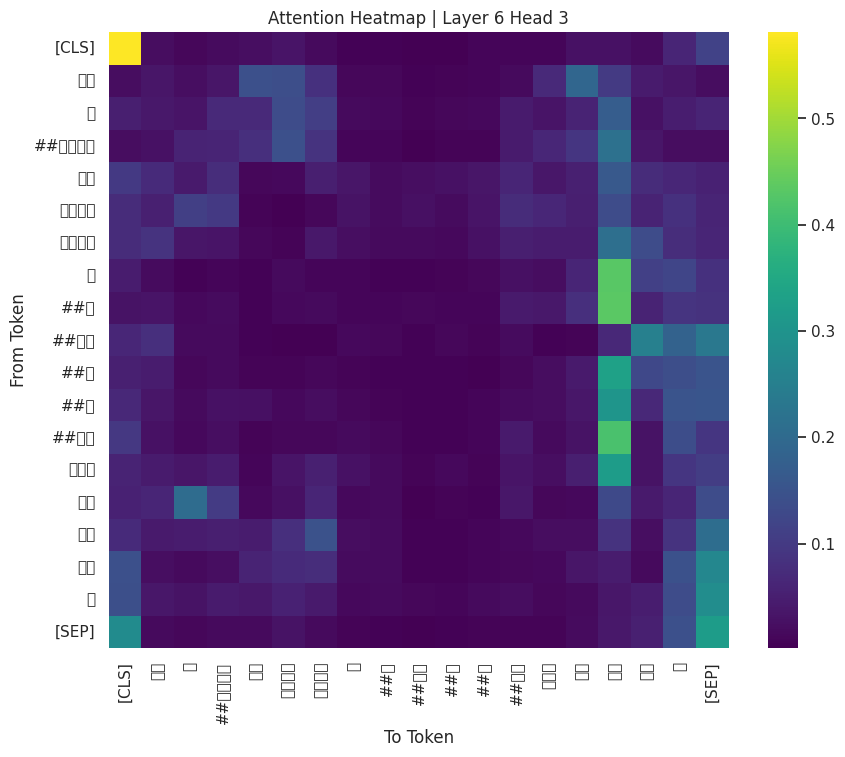


Top heads for this sentence:
     Layer  Head  Accuracy
72       7     1       0.5
2        1     3       0.4
68       6     9       0.4
136     12     5       0.4
97       9     2       0.4
3        1     4       0.3
14       2     3       0.3
9        1    10       0.3
63       6     4       0.3
57       5    10       0.3


100%|██████████| 1000/1000 [00:26<00:00, 38.30it/s]



Top Overall Grammar Heads:
     Layer  Head  Accuracy
70       6    11  0.274278
79       7     8  0.268809
123     11     4  0.243613
92       8     9  0.241557
14       2     3  0.234453
81       7    10  0.233215
118     10    11  0.232967
63       6     4  0.228348
31       3     8  0.227798
61       6     2  0.217696
95       8    12  0.215240
139     12     8  0.213586
97       9     2  0.212852
6        1     7  0.210115
120     11     1  0.208371


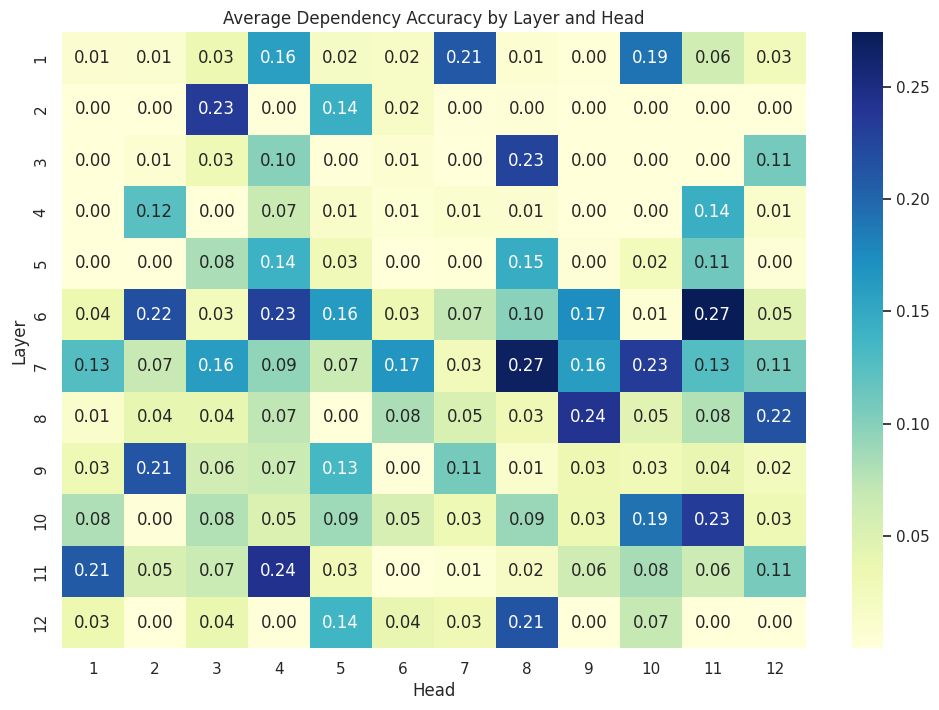

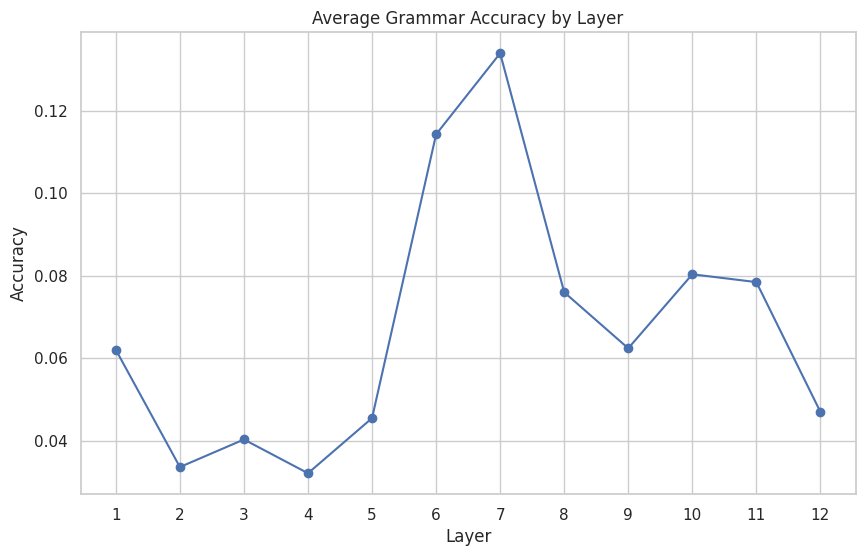


BEST HEAD FOUND:
Layer        6.000000
Head        11.000000
Accuracy     0.274278
Name: 70, dtype: float64

Saved file: bert_ud_results.csv

Project Interpretation:

1. Higher accuracy means that attention head aligns with dependency grammar.
2. Compare layers:
   - Early layers = lexical / POS
   - Middle layers = syntax
   - Later layers = semantics
3. If middle layers score highest, it supports grammar emergence.



In [2]:

# Project: Do LLMs develop dependency grammar?

!pip -q install transformers datasets torch seaborn matplotlib pandas numpy


import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from transformers import BertTokenizer, BertModel
from datasets import load_dataset
from tqdm import tqdm

sns.set(style="whitegrid")

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)


tokenizer = BertTokenizer.from_pretrained("bert-base-multilingual-cased")

model = BertModel.from_pretrained(
    "bert-base-multilingual-cased",
    output_attentions=True
)

model.to(device)
model.eval()

print("BERT loaded successfully")


!pip -q install conllu requests

import requests
from conllu import parse


url = "https://raw.githubusercontent.com/UniversalDependencies/UD_Hindi-HDTB/master/hi_hdtb-ud-train.conllu"

data = requests.get(url).text

sentences = parse(data)

print("Total Sentences Loaded:", len(sentences))




def clean_sentence(tokens):
    """
    Convert token list to sentence text
    """
    return " ".join(tokens)


def get_model_attention(sentence):
    """
    Run sentence through BERT and return attentions + tokens
    """
    inputs = tokenizer(
        sentence,
        return_tensors="pt",
        truncation=True,
        max_length=128
    )

    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    attentions = outputs.attentions
    token_ids = inputs["input_ids"][0]
    bert_tokens = tokenizer.convert_ids_to_tokens(token_ids)

    return attentions, bert_tokens


def dependency_pairs(heads):
    """
    Convert head list into child-parent pairs
    Example: [2,3,0,3]
    Returns [(1,2),(2,3),(4,3)]
    """
    pairs = []

    for child_idx, parent_idx in enumerate(heads, start=1):
        if parent_idx != 0:
            pairs.append((child_idx, parent_idx))

    return pairs


def score_attention_head(attn_matrix, gold_heads):
    """
    Compare attention with gold dependency heads
    child predicts parent using argmax
    """
    correct = 0
    total = 0

    for child_idx, parent_idx in enumerate(gold_heads, start=1):

        if parent_idx == 0:
            continue

        
        pred = np.argmax(attn_matrix[child_idx])

        if pred == parent_idx:
            correct += 1

        total += 1

    if total == 0:
        return 0

    return correct / total


def visualize_attention(attentions, bert_tokens, layer=6, head=0):
    """
    Plot one attention head heatmap
    """
    matrix = attentions[layer][0, head].cpu().numpy()

    plt.figure(figsize=(10,8))
    sns.heatmap(
        matrix,
        xticklabels=bert_tokens,
        yticklabels=bert_tokens,
        cmap="viridis"
    )

    plt.title(f"Attention Heatmap | Layer {layer+1} Head {head+1}")
    plt.xlabel("To Token")
    plt.ylabel("From Token")
    plt.show()



sample = sentences[0]

words = [token["form"] for token in sample]
heads = [token["head"] for token in sample]

sentence = clean_sentence(words)

print("Sentence:")
print(sentence)

print("\nGold Heads:")
print(heads)

attentions, bert_tokens = get_model_attention(sentence)

print("\nBERT Tokens:")
print(bert_tokens)


visualize_attention(attentions, bert_tokens, layer=5, head=2)


results = []

for layer in range(12):
    for head in range(12):

        matrix = attentions[layer][0, head].cpu().numpy()

        acc = score_attention_head(matrix, heads)

        results.append([layer+1, head+1, acc])

df_one = pd.DataFrame(results, columns=["Layer", "Head", "Accuracy"])

print("\nTop heads for this sentence:")
print(df_one.sort_values("Accuracy", ascending=False).head(10))


NUM_SENTENCES = 1000   

all_scores = []

for idx in tqdm(range(NUM_SENTENCES)):

    try:
        sample = sentences[idx]

        words = [token["form"] for token in sample]
        heads = [token["head"] for token in sample]

        
        if len(words) > 30:
            continue

        sentence = clean_sentence(words)

        attentions, bert_tokens = get_model_attention(sentence)

        
        if len(bert_tokens) > 60:
            continue

        for layer in range(12):
            for head in range(12):

                matrix = attentions[layer][0, head].cpu().numpy()

                acc = score_attention_head(matrix, heads)

                all_scores.append([layer+1, head+1, acc])

    except:
        continue


df = pd.DataFrame(all_scores, columns=["Layer", "Head", "Accuracy"])

avg_df = (
    df.groupby(["Layer", "Head"])["Accuracy"]
    .mean()
    .reset_index()
)

print("\nTop Overall Grammar Heads:")
print(avg_df.sort_values("Accuracy", ascending=False).head(15))


pivot = avg_df.pivot(index="Layer", columns="Head", values="Accuracy")

plt.figure(figsize=(12,8))
sns.heatmap(
    pivot,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu"
)

plt.title("Average Dependency Accuracy by Layer and Head")
plt.xlabel("Head")
plt.ylabel("Layer")
plt.show()


layer_avg = (
    avg_df.groupby("Layer")["Accuracy"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10,6))
plt.plot(layer_avg["Layer"], layer_avg["Accuracy"], marker="o")
plt.title("Average Grammar Accuracy by Layer")
plt.xlabel("Layer")
plt.ylabel("Accuracy")
plt.xticks(range(1,13))
plt.show()


best = avg_df.sort_values("Accuracy", ascending=False).iloc[0]

print("\nBEST HEAD FOUND:")
print(best)


avg_df.to_csv("bert_ud_results.csv", index=False)

print("\nSaved file: bert_ud_results.csv")


print("\nProject Interpretation:")
print("""
1. Higher accuracy means that attention head aligns with dependency grammar.
2. Compare layers:
   - Early layers = lexical / POS
   - Middle layers = syntax
   - Later layers = semantics
3. If middle layers score highest, it supports grammar emergence.
""")